In [52]:
import pandas as pd
import warnings
import joblib
from sklearn.metrics import make_scorer
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

%run model_research.ipynb
%run splitted_df_validation.ipynb

In [2]:
warnings.filterwarnings("ignore")
df_trades = pd.read_csv('btc_trades_no_overlap.csv')


In [3]:
df_train, df_test, validation_df = create_train_valid_df(df_trades)

print(f'validation len is: {len(validation_df)}')

2768
1844
train lenght is:1844
test lenght is:924
validation len is: 2769


first iter of training will be a random search of crossed random params with random features, the goal is to find models that can generalize well keeping a consistent recall, the test will be done on the entire test population, once the model will be considered complete the next test for the ecaluation will be a recursive training on the test population keeping small sets aprox 50 to 100 (the goal is to evaluate the model response on changes in market structure and evaluating drowdowns), once the model is trained last test will be test it on entire validation pupulation and recursive test on validation to check for the model consistency

In [7]:
features = ['Close',
       'Volume', 'fast_period', 'slow_period', 'macd', 'signal',
       'hist', 'atr', 'Trade_Direction', 'stop_loss', 'recent_high_fast',
       'recent_low_fast', 'recent_high_med', 'recent_low_med',
       'recent_high_slow', 'recent_low_slow', 'from_high_fast',
       'from_low_fast', 'from_high_med', 'from_low_med', 'from_high_slow',
       'from_low_slow', 'sar', 'Rsi_9', 'Rsi_14', 'volatility_15min',
       'high_volatility_15min', 'volatility_1h', 'high_volatility',
       'trend_strenght_4h', 'strong_trend', 'price_change_4h', 'range_bound',
       'ema_50', 'ema_200', 'ema_50_slope', 'ema_200_slope', 'ratio_ema_50',
       'ratio_ema_200', 'above_ema_50', 'above_ema_200',
       'distance_from_ema_50', 'distance_from_ema_200']


In [10]:
best_models_df = optimize_model(model_features = features, param_func = generate_random_params,
                                n_iter = 50000,
                                df_train = df_train, df_test = df_test,
                                model = XGBClassifier,
                                min_prec = 0.39, min_rec = 0.2)



new optimization found, iter n: 5, precision: 0.42777777777777776, reacll: 0.22916666666666666, n_features: 22, score: 0.29844961240310075
new optimization found, iter n: 25, precision: 0.39568345323741005, reacll: 0.49107142857142855, n_features: 34, score: 0.43824701195219123
new optimization found, iter n: 49, precision: 0.3957845433255269, reacll: 0.5029761904761905, n_features: 35, score: 0.4429882044560944
new optimization found, iter n: 96, precision: 0.39539748953974896, reacll: 0.5625, n_features: 31, score: 0.4643734643734644
new optimization found, iter n: 112, precision: 0.3943089430894309, reacll: 0.5773809523809523, n_features: 32, score: 0.46859903381642515
new optimization found, iter n: 222, precision: 0.39097744360902253, reacll: 0.6190476190476191, n_features: 25, score: 0.4792626728110599
new optimization found, iter n: 226, precision: 0.39313572542901715, reacll: 0.75, n_features: 12, score: 0.5158648925281474
new optimization found, iter n: 968, precision: 0.39263

In [30]:
#create a list of all present features wuth the number of times they appear in the df
feature_counts = best_models_df['features'].explode().value_counts()
#select top 60% of features
feature_counts_cut = int(len(feature_counts)*0.60)
features_to_test = feature_counts[:feature_counts_cut]
#create a list with the features
features_to_test = features_to_test.index.tolist()

In [31]:
test_2_df = optimize_model(model_features = features_to_test, param_func = generate_random_params,
                                n_iter = 50000,
                                df_train = df_train, df_test = df_test,
                                model = XGBClassifier,
                                min_prec = 0.39, min_rec = 0.2)


new optimization found, iter n: 168, precision: 0.40476190476190477, reacll: 0.6577380952380952, n_features: 10, score: 0.5011337868480725
new optimization found, iter n: 263, precision: 0.3918305597579425, reacll: 0.7708333333333334, n_features: 3, score: 0.5195586760280843
new optimization found, iter n: 597, precision: 0.3919523099850969, reacll: 0.7827380952380952, n_features: 5, score: 0.522343594836147
new optimization found, iter n: 1542, precision: 0.39002932551319647, reacll: 0.7916666666666666, n_features: 17, score: 0.5225933202357563
new optimization found, iter n: 3703, precision: 0.3953823953823954, reacll: 0.8154761904761905, n_features: 14, score: 0.532555879494655
new optimization found, iter n: 7765, precision: 0.394109396914446, reacll: 0.8363095238095238, n_features: 12, score: 0.5357483317445186
new optimization found, iter n: 15825, precision: 0.3935064935064935, reacll: 0.9017857142857143, n_features: 14, score: 0.5479204339963833
new optimization found, iter n: 

In [32]:
new_feature_counts = test_2_df['features'].explode().value_counts()
new_feature_cut = int(len(new_feature_counts)*0.75)
features_to_optimize = (new_feature_counts[:new_feature_cut]).index.tolist()


In [33]:
test_3_df = optimize_model(model_features = features_to_optimize, param_func = generate_random_params,
                                n_iter = 50000,
                                df_train = df_train, df_test = df_test,
                                model = XGBClassifier,
                                min_prec = 0.39, min_rec = 0.2)

new optimization found, iter n: 30, precision: 0.4034653465346535, reacll: 0.4851190476190476, n_features: 9, score: 0.44054054054054054
new optimization found, iter n: 44, precision: 0.40794979079497906, reacll: 0.5803571428571429, n_features: 15, score: 0.47911547911547914
new optimization found, iter n: 75, precision: 0.3938814531548757, reacll: 0.6130952380952381, n_features: 12, score: 0.479627473806752
new optimization found, iter n: 86, precision: 0.3920863309352518, reacll: 0.6488095238095238, n_features: 15, score: 0.48878923766816146
new optimization found, iter n: 109, precision: 0.3964401294498382, reacll: 0.7291666666666666, n_features: 14, score: 0.5136268343815513
new optimization found, iter n: 172, precision: 0.4065040650406504, reacll: 0.7440476190476191, n_features: 6, score: 0.5257623554153522
new optimization found, iter n: 394, precision: 0.3924380704041721, reacll: 0.8958333333333334, n_features: 15, score: 0.5457842248413418
new optimization found, iter n: 1214,

seeing the results i can assume that most models have a precision around 39% with very high recall, it happens that a single model reaches almost 43% precision with 30% recall, my first way to optimize the model will be choosing top 30% of features and using baynes on others, if the results are not positive second trial will be choosing directitly the features from best model
scoring should be inmproved to get a more balanced relationship between precision and recall, current scoring:

    def simple_scorer(y_test, y_pred, min_prec = 0.4, min_rec = 0.5):
    
        prec = precision_score(y_test, y_pred, pos_label = 1)
        rec = recall_score(y_test, y_pred, pos_label = 1)
        f1 = f1_score(y_test, y_pred)
    
        hard_constraint_penalty = 0.6 if (prec < min_prec) or (rec < min_rec) else 0.0
    
        score = f1 - hard_constraint_penalty
    
        return score 

new scorer to test

scoring = make_scorer(fbeta_score, beta=0.5, pos_label=1)


In [ ]:
#now i want to see the final choice for features and go for a randomsearchCV

In [34]:
final_feature_counts = test_3_df['features'].explode().value_counts()
final_feature_cut = int(len(final_feature_counts)*0.75)
features_to_use = (final_feature_counts[:final_feature_cut]).index.tolist()
print(features_to_use)

['volatility_1h', 'above_ema_50', 'distance_from_ema_200', 'ema_50_slope', 'Volume', 'volatility_15min', 'distance_from_ema_50', 'from_high_med', 'from_high_fast', 'recent_low_slow', 'from_low_fast', 'Close', 'recent_high_slow']


In [40]:
from sklearn.metrics import fbeta_score

param_distributions_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 1, 10],
    'reg_lambda': [1, 10, 100],
    'scale_pos_weight': [1, 3, 5, 10],
    'tree_method': ['hist', 'auto']
}

scorer = make_scorer(fbeta_score, beta = 0.25, pos_label = 1)
#note: after a first test beta = 0.5 seems to high, search prefered a model with 0.37 prec and 0.97 rec over all
model = XGBClassifier()

random_search = RandomizedSearchCV(
    estimator = model,
    param_distributions = param_distributions_xgb,
    n_iter = 200,  # Number of parameter combinations to try
    scoring = scorer,  # Use F0.5 score (precision-focused)
    cv = 5,  # 5-fold cross-validation
    verbose = 1,  # Show progress
    random_state = 42,
    n_jobs = -1,  # Use all available cores
    return_train_score = True  # Track overfitting
)
X_train = df_train[features_to_use]
y_train = df_train['Trades']
X_test = df_test[features_to_use]
y_test = df_test['Trades']
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
test_precision = precision_score(y_test, y_pred, pos_label=1)
test_recall = recall_score(y_test, y_pred, pos_label=1)
print(f"Precision: {test_precision}")
print(f"Recall:    {test_recall}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Precision: 0.44502617801047123
Recall:    0.25297619047619047


this result fit much more to the standard i want to have, next step is to check if the model is consistent in a recursive training over the test sample and check how precision and recall change, the recursive training should start with a warm training

In [41]:
#first let's check how the model predict the test df as it is now
section_df = section_validation(df_test, best_model, features_to_use)

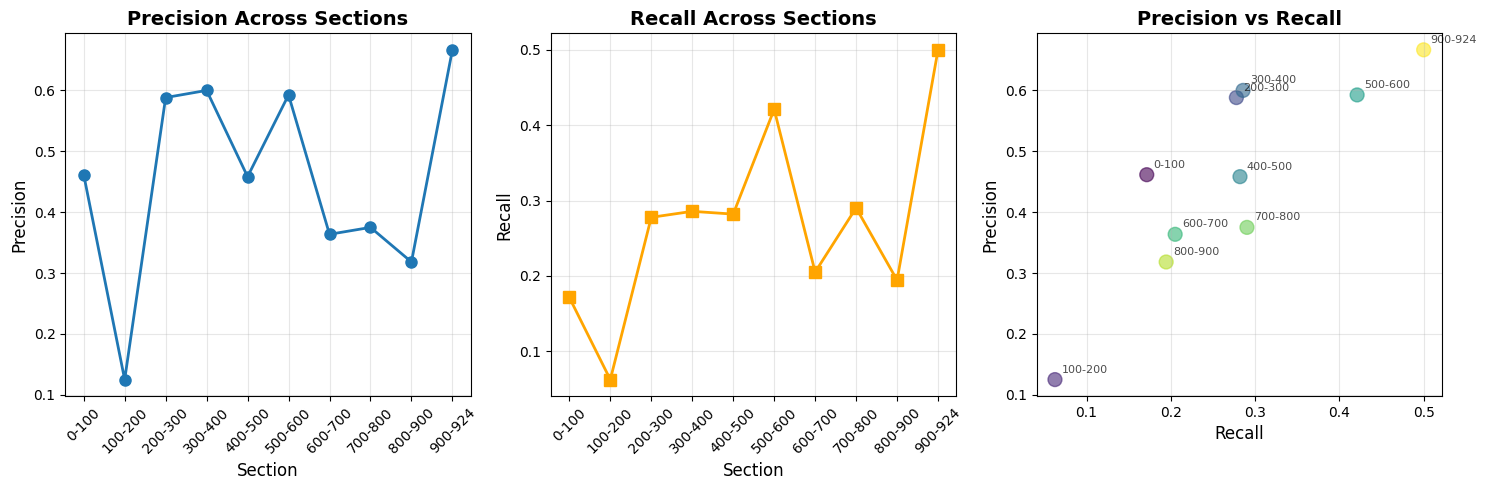

In [43]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Precision over sections
axes[0].plot(section_df['section'], section_df['precision'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Section', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision Across Sections', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot 2: Recall over sections
axes[1].plot(section_df['section'], section_df['recall'], marker='s', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('Section', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Recall Across Sections', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
axes[2].scatter(section_df['recall'], section_df['precision'], s=100, alpha=0.6, 
                c=range(len(section_df)), cmap='viridis')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Add section labels to the scatter plot
for i, row in section_df.iterrows():
    axes[2].annotate(row['section'], (row['recall'], row['precision']), 
                    fontsize=8, alpha=0.7, xytext=(5, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

the model despite having high variability seems to have good results

In [54]:
#model to retrain is best model
model_to_use = best_model
#100 samples per cut
cut_len = 100
cut_num = int(round(len(df_test) / cut_len))
start_idx = 0
end_idx = 0
results_list = []
for cut in range(cut_num):
    
    end_idx = start_idx + cut_len
    current_split = df_test[start_idx:end_idx]
    
    if cut == 0:
        
        precision, recall = test_model(df = current_split, model = model_to_use,
                                       features = features_to_use)
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

    else:

        train_split = df_test[:end_idx - cut_len]
        X_train = train_split[features_to_use]
        y_train = train_split['Trades']

        old_model = model_to_use
        old_params = old_model.get_params()
        old_booster = old_model.get_booster()
        model = XGBClassifier(**old_params)
        model.fit(X_train, y_train, xgb_model = old_booster)
        precision, recall = test_model(df = current_split, model = model,
                                       features = features_to_use)
        
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

recursive_results_df = pd.DataFrame(results_list)
    
    
        
        




model precision is 0.46153846153846156
model recall is 0.17142857142857143
model precision is 0.25
model recall is 0.1875
model precision is 0.5263157894736842
model recall is 0.2777777777777778
model precision is 0.5517241379310345
model recall is 0.38095238095238093
model precision is 0.4444444444444444
model recall is 0.20512820512820512
model precision is 0.5862068965517241
model recall is 0.4473684210526316
model precision is 0.3548387096774194
model recall is 0.28205128205128205
model precision is 0.4117647058823529
model recall is 0.22580645161290322
model precision is 0.45454545454545453
model recall is 0.2777777777777778


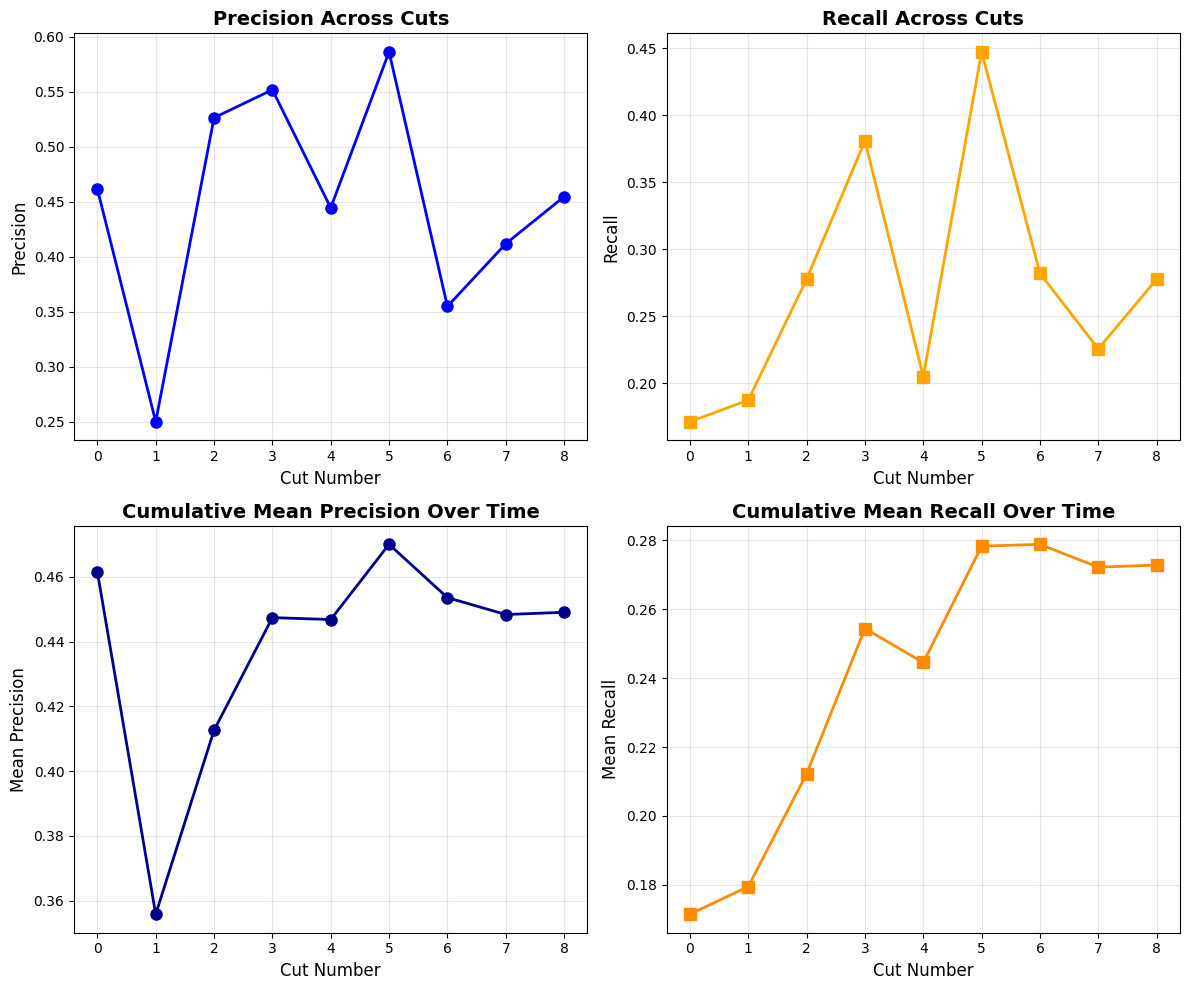

In [56]:

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Precision over cut_number
axes[0, 0].plot(recursive_results_df['cut_number'], recursive_results_df['precision'], 
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Cut Number', fontsize=12)
axes[0, 0].set_ylabel('Precision', fontsize=12)
axes[0, 0].set_title('Precision Across Cuts', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Recall over cut_number
axes[0, 1].plot(recursive_results_df['cut_number'], recursive_results_df['recall'], 
             marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Cut Number', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Recall Across Cuts', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calculate cumulative means
recursive_results_df['cumulative_mean_precision'] = recursive_results_df['precision'].expanding().mean()
recursive_results_df['cumulative_mean_recall'] = recursive_results_df['recall'].expanding().mean()

# Plot 3: Cumulative Mean Precision over cut_number
axes[1, 0].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_precision'], 
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[1, 0].set_xlabel('Cut Number', fontsize=12)
axes[1, 0].set_ylabel('Mean Precision', fontsize=12)
axes[1, 0].set_title('Cumulative Mean Precision Over Time', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Mean Recall over cut_number
axes[1, 1].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_recall'], 
             marker='s', linewidth=2, markersize=8, color='darkorange')
axes[1, 1].set_xlabel('Cut Number', fontsize=12)
axes[1, 1].set_ylabel('Mean Recall', fontsize=12)
axes[1, 1].set_title('Cumulative Mean Recall Over Time', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

the model seems to be consistent over time with the recursive training method

In [57]:
#model to retrain is best model
model_to_use = model
#100 samples per cut
cut_len = 100
cut_num = int(round(len(validation_df) / cut_len))
start_idx = 0
end_idx = 0
results_list = []
for cut in range(cut_num):
    
    end_idx = start_idx + cut_len
    current_split = validation_df[start_idx:end_idx]
    
    if cut == 0:
        
        precision, recall = test_model(df = current_split, model = model_to_use,
                                       features = features_to_use)
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

    else:

        train_split = validation_df[:end_idx - cut_len]
        X_train = train_split[features_to_use]
        y_train = train_split['Trades']

        old_model = model_to_use
        old_params = old_model.get_params()
        old_booster = old_model.get_booster()
        model = XGBClassifier(**old_params)
        model.fit(X_train, y_train, xgb_model = old_booster)
        precision, recall = test_model(df = current_split, model = model,
                                       features = features_to_use)
        
        results_list.append({
            'cut_number': cut,
            'start_idx': start_idx,
            'end_Index': end_idx,
            'precision': precision,
            'recall': recall
        })
        start_idx = end_idx

recursive_results_df = pd.DataFrame(results_list)
    
    
        
        




model precision is 0.22727272727272727
model recall is 0.14285714285714285
model precision is 0.325
model recall is 0.37142857142857144
model precision is 0.3125
model recall is 0.15151515151515152
model precision is 0.35
model recall is 0.18421052631578946
model precision is 0.38461538461538464
model recall is 0.2857142857142857
model precision is 0.25
model recall is 0.2727272727272727
model precision is 0.4117647058823529
model recall is 0.3783783783783784
model precision is 0.3
model recall is 0.2727272727272727
model precision is 0.42857142857142855
model recall is 0.225
model precision is 0.3142857142857143
model recall is 0.3055555555555556
model precision is 0.3157894736842105
model recall is 0.42857142857142855
model precision is 0.4
model recall is 0.15384615384615385
model precision is 0.3793103448275862
model recall is 0.36666666666666664
model precision is 0.21875
model recall is 0.2
model precision is 0.5294117647058824
model recall is 0.24324324324324326
model precision 

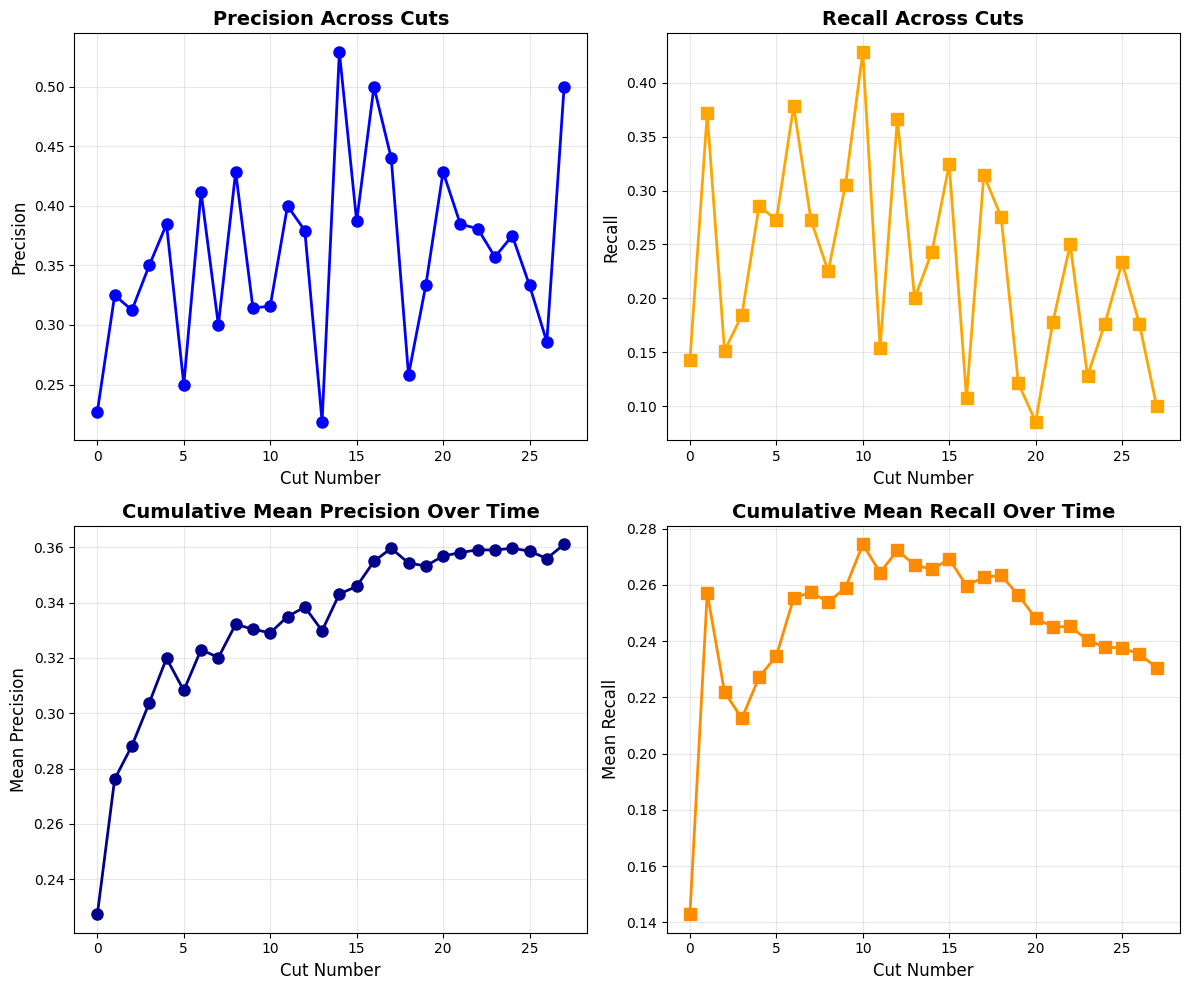

In [58]:

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Precision over cut_number
axes[0, 0].plot(recursive_results_df['cut_number'], recursive_results_df['precision'], 
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Cut Number', fontsize=12)
axes[0, 0].set_ylabel('Precision', fontsize=12)
axes[0, 0].set_title('Precision Across Cuts', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Recall over cut_number
axes[0, 1].plot(recursive_results_df['cut_number'], recursive_results_df['recall'], 
             marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Cut Number', fontsize=12)
axes[0, 1].set_ylabel('Recall', fontsize=12)
axes[0, 1].set_title('Recall Across Cuts', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calculate cumulative means
recursive_results_df['cumulative_mean_precision'] = recursive_results_df['precision'].expanding().mean()
recursive_results_df['cumulative_mean_recall'] = recursive_results_df['recall'].expanding().mean()

# Plot 3: Cumulative Mean Precision over cut_number
axes[1, 0].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_precision'], 
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[1, 0].set_xlabel('Cut Number', fontsize=12)
axes[1, 0].set_ylabel('Mean Precision', fontsize=12)
axes[1, 0].set_title('Cumulative Mean Precision Over Time', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Mean Recall over cut_number
axes[1, 1].plot(recursive_results_df['cut_number'], recursive_results_df['cumulative_mean_recall'], 
             marker='s', linewidth=2, markersize=8, color='darkorange')
axes[1, 1].set_xlabel('Cut Number', fontsize=12)
axes[1, 1].set_ylabel('Mean Recall', fontsize=12)
axes[1, 1].set_title('Cumulative Mean Recall Over Time', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

model is obv overfitted